# Mid-price session overview

MNQ MBP-1 mid price for a single Globex day (`2025-09-15`), saved to `notebooks/figures/day_session.png`.

![day_session](figures/day_session.png)


In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
print("cwd:", Path.cwd())


cwd: /home/johnh/projects/microstructure-benchmark


In [2]:
import matplotlib.pyplot as plt
from src.data_io import load_mbp1, add_mid_and_spread

DATE = "2025-09-15"
lf = add_mid_and_spread(load_mbp1(DATE, "2025-09-16"))
df = lf.select(["ts_event", "mid"]).collect()

# Downsample so the plot stays responsive (~50k points max).
step = max(1, df.height // 50_000)
plot_df = df[::step]
print(f"rows={df.height:,} plotted={plot_df.height:,}")


rows=5,484,772 plotted=50,320


saved: /home/johnh/projects/microstructure-benchmark/notebooks/figures/day_session.png


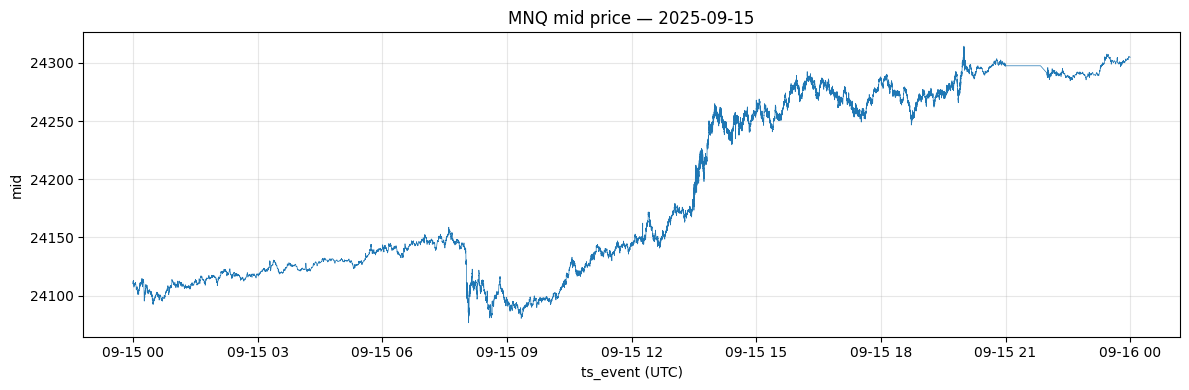

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plot_df["ts_event"], plot_df["mid"], linewidth=0.5)
ax.set_title(f"MNQ mid price — {DATE}")
ax.set_xlabel("ts_event (UTC)")
ax.set_ylabel("mid")
ax.grid(True, alpha=0.3)
fig.tight_layout()

out = Path("notebooks/figures/day_session.png")
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=120)
print("saved:", out.resolve())
plt.show()


# Session microstructure EDA

Exploratory plots over the bulk download window:

- Mid price across three representative sessions
- Average spread by 5-minute bucket (by weekday)
- Trade-count-per-second distribution
- Trade volume by hour of day (US/Eastern)


In [4]:
# Shared window for session plots
import polars as pl
import matplotlib.pyplot as plt
from src.config import DATA_START, DATA_END
from src.data_io import load_mbp1, add_mid_and_spread

# Full window, lazy — only collect after aggregating
window = add_mid_and_spread(load_mbp1(DATA_START, DATA_END))
print("window:", DATA_START, "->", DATA_END)


window: 2025-09-15 -> 2025-10-04


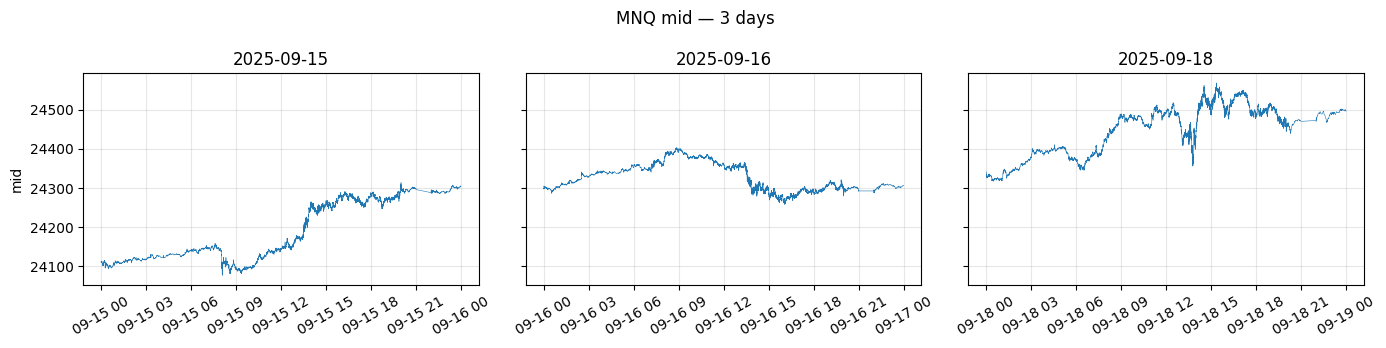

In [5]:
# Mid price: three sessions side by side
from datetime import date as date_cls, timedelta

dates = ["2025-09-15", "2025-09-16", "2025-09-18"]  # exclude 2025-09-17 (Databento degraded quality)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)

for ax, day in zip(axes, dates):
    d1 = (date_cls.fromisoformat(day) + timedelta(days=1)).isoformat()
    df = (
        add_mid_and_spread(load_mbp1(day, d1))
        .select(["ts_event", "mid"])
        .collect()
    )
    step = max(1, df.height // 20_000)
    plot_df = df[::step]
    ax.plot(plot_df["ts_event"], plot_df["mid"], linewidth=0.4)
    ax.set_title(day)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", labelrotation=30)

axes[0].set_ylabel("mid")
fig.suptitle("MNQ mid — 3 days")
fig.tight_layout()
plt.show()



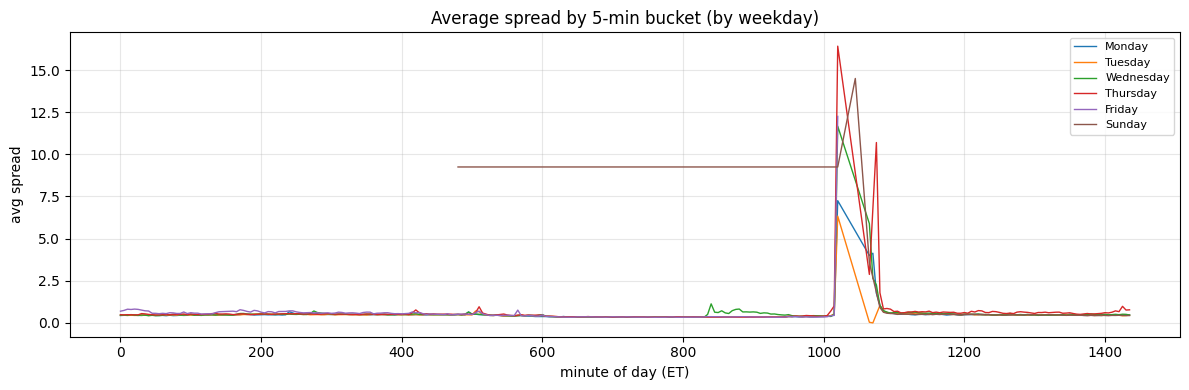

In [6]:
# Average spread by 5-minute bucket (by weekday)
spread_by_wd = (
    window.select(["ts_event", "spread"])
    .with_columns(
        pl.col("ts_event").dt.convert_time_zone("America/New_York").alias("ts_et")
    )
    .with_columns(
        pl.col("ts_et").dt.strftime("%A").alias("weekday"),
        (
            pl.col("ts_et").dt.hour().cast(pl.Int32) * 60
            + pl.col("ts_et").dt.minute().cast(pl.Int32)
        )
        .floordiv(5)
        .mul(5)
        .alias("minute_of_day"),
    )
    .group_by(["weekday", "minute_of_day"])
    .agg(pl.col("spread").mean().alias("avg_spread"))
    .sort(["weekday", "minute_of_day"])
    .collect()
)

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Sunday"]
fig, ax = plt.subplots(figsize=(12, 4))
for wd in weekday_order:
    sub = spread_by_wd.filter(pl.col("weekday") == wd)
    if sub.height == 0:
        continue
    ax.plot(sub["minute_of_day"], sub["avg_spread"], label=wd, linewidth=1)

ax.set_xlabel("minute of day (ET)")
ax.set_ylabel("avg spread")
ax.set_title("Average spread by 5-min bucket (by weekday)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


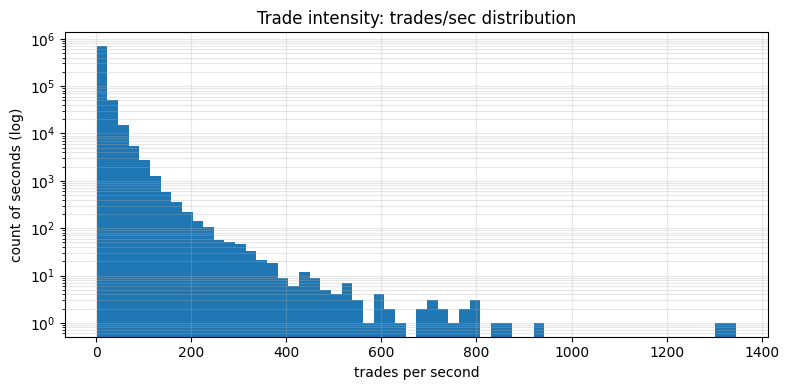

shape: (1, 2)
┌──────────┬──────┐
│ mean     ┆ max  │
│ ---      ┆ ---  │
│ f64      ┆ u32  │
╞══════════╪══════╡
│ 9.405851 ┆ 1346 │
└──────────┴──────┘


In [7]:
# Trade count per second (histogram, log y)
trade_counts = (
    window.filter(pl.col("action") == "T")
    .with_columns(pl.col("ts_event").dt.truncate("1s").alias("sec"))
    .group_by("sec")
    .agg(pl.len().alias("n_trades"))
    .collect()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(trade_counts["n_trades"], bins=60)
ax.set_yscale("log")
ax.set_xlabel("trades per second")
ax.set_ylabel("count of seconds (log)")
ax.set_title("Trade intensity: trades/sec distribution")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()
print(trade_counts.select(pl.col("n_trades").mean().alias("mean"), pl.col("n_trades").max().alias("max")))


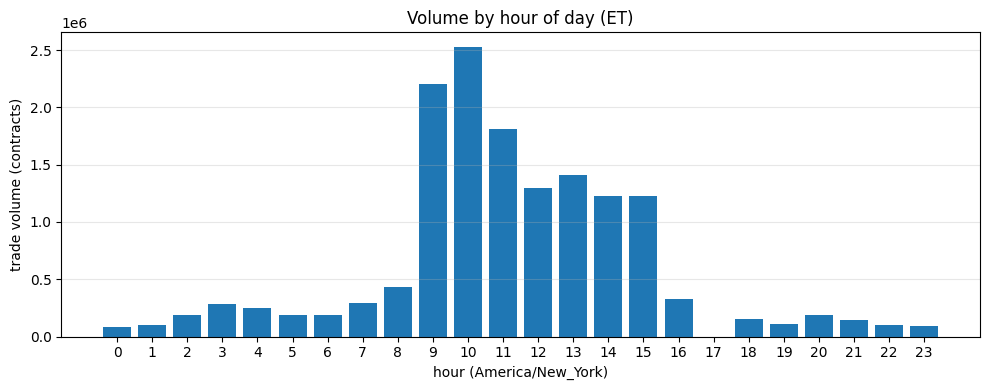

shape: (23, 2)
┌─────────┬────────┐
│ hour_et ┆ volume │
│ ---     ┆ ---    │
│ i8      ┆ u32    │
╞═════════╪════════╡
│ 0       ┆ 85972  │
│ 1       ┆ 104797 │
│ 2       ┆ 191298 │
│ 3       ┆ 281787 │
│ 4       ┆ 246955 │
│ …       ┆ …      │
│ 19      ┆ 109103 │
│ 20      ┆ 188801 │
│ 21      ┆ 144238 │
│ 22      ┆ 101836 │
│ 23      ┆ 94745  │
└─────────┴────────┘


In [8]:
# Trade volume by hour of day (US/Eastern)
# volume ≈ sum of trade sizes
vol_by_hour = (
    window.filter(pl.col("action") == "T")
    .with_columns(
        pl.col("ts_event")
        .dt.convert_time_zone("America/New_York")
        .dt.hour()
        .alias("hour_et")
    )
    .group_by("hour_et")
    .agg(pl.col("size").sum().alias("volume"))
    .sort("hour_et")
    .collect()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(vol_by_hour["hour_et"], vol_by_hour["volume"])
ax.set_xlabel("hour (America/New_York)")
ax.set_ylabel("trade volume (contracts)")
ax.set_title("Volume by hour of day (ET)")
ax.set_xticks(list(range(24)))
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()
print(vol_by_hour)
